In [1]:
#Import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
#Function to Expore the input data/EDA
def LoadData_Explore(filename):
    df = None
    try:
        df = pd.read_csv(filename)
        print("Data loaded into dataframe successfully!!")
        print("Please find the shape of the data as follows:")
        display(df.shape)
        print("Please find the first 5 rows of data as follows:")
        display(df.head())
        print("Please find the last 5 rows of data as follows:")
        display(df.tail())
        print("Please find the information on the data and data type as follows:")
        display(df.info())
        print("Please find the descriptive stats for numeric columns as follows:")
        display(df.describe())
        print("Please find the descriptive stats for non numeric columns as follows:")
        display(df.describe(include='O'))
        print("Lets check the data types for all the columns in data:")
        display(df.dtypes)    
    except FileNotFoundError:
        print(f"Error: {filename} not found!")
    return df 

In [4]:
#Load data from csv file
df = LoadData_Explore('LoanData.csv')

Data loaded into dataframe successfully!!
Please find the shape of the data as follows:


(10, 7)

Please find the first 5 rows of data as follows:


,Age,AnnualIncome(lakhs),CreditScore(300-900),LoanAmount(lakhs),LoanTerm(years),EmploymentType,loan(yes/no)
0,28,6.5,720,5,5,Salaried,0
1,45,12.0,680,10,10,Self-Employed,1
2,35,8.0,750,6,7,Salaried,0
3,50,15.0,640,12,15,Self-Employed,1
4,30,7.0,710,5,5,Salaried,0


Please find the last 5 rows of data as follows:


,Age,AnnualIncome(lakhs),CreditScore(300-900),LoanAmount(lakhs),LoanTerm(years),EmploymentType,loan(yes/no)
5,42,10.0,660,9,10,Salaried,1
6,26,5.5,730,4,4,Salaried,0
7,48,14.0,650,11,12,Self-Employed,1
8,38,9.0,700,7,8,Salaried,0
9,55,16.0,620,13,15,Self-Employed,1


Please find the information on the data and data type as follows:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   10 non-null     int64  
 1   AnnualIncome(lakhs)   10 non-null     float64
 2   CreditScore(300-900)  10 non-null     int64  
 3    LoanAmount(lakhs)    10 non-null     int64  
 4    LoanTerm(years)      10 non-null     int64  
 5    EmploymentType       10 non-null     object 
 6    loan(yes/no)         10 non-null     int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 692.0+ bytes


None

Please find the descriptive stats for numeric columns as follows:


,Age,AnnualIncome(lakhs),CreditScore(300-900),LoanAmount(lakhs),LoanTerm(years),loan(yes/no)
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,39.700000,10.300000,686.000000,8.200000,9.100000,0.500000
std,9.922477,3.750556,42.739521,3.224903,4.012481,0.527046
min,26.000000,5.500000,620.000000,4.000000,4.000000,0.000000
25%,31.250000,7.250000,652.500000,5.250000,5.500000,0.000000
50%,40.000000,9.500000,690.000000,8.000000,9.000000,0.500000
75%,47.250000,13.500000,717.500000,10.750000,11.500000,1.000000
max,55.000000,16.000000,750.000000,13.000000,15.000000,1.000000


Please find the descriptive stats for non numeric columns as follows:


,EmploymentType
count,10
unique,2
top,Salaried
freq,6


Lets check the data types for all the columns in data:


Age                       int64
AnnualIncome(lakhs)     float64
CreditScore(300-900)      int64
 LoanAmount(lakhs)        int64
 LoanTerm(years)          int64
 EmploymentType          object
 loan(yes/no)             int64
dtype: object

In [5]:
#Perform Null and Duplicate check
df.isna().any().any()

np.False_

In [6]:
df.duplicated().any()

np.False_

OBSERVATION: Data doesn't have any nulls or duplicates.

In [7]:
#Lets encode the catgorical columns 
df = pd.get_dummies(df, columns=[' EmploymentType'], drop_first=True)
df

,Age,AnnualIncome(lakhs),CreditScore(300-900),LoanAmount(lakhs),LoanTerm(years),loan(yes/no),EmploymentType_Self-Employed
0,28,6.5,720,5,5,0,False
1,45,12.0,680,10,10,1,True
2,35,8.0,750,6,7,0,False
3,50,15.0,640,12,15,1,True
4,30,7.0,710,5,5,0,False
5,42,10.0,660,9,10,1,False
6,26,5.5,730,4,4,0,False
7,48,14.0,650,11,12,1,True
8,38,9.0,700,7,8,0,False
9,55,16.0,620,13,15,1,True


In [8]:
#Lets convert TRUE/FALSE as 1/0
df[' EmploymentType_Self-Employed'] = df[' EmploymentType_Self-Employed'].astype(int)
df

,Age,AnnualIncome(lakhs),CreditScore(300-900),LoanAmount(lakhs),LoanTerm(years),loan(yes/no),EmploymentType_Self-Employed
0,28,6.5,720,5,5,0,0
1,45,12.0,680,10,10,1,1
2,35,8.0,750,6,7,0,0
3,50,15.0,640,12,15,1,1
4,30,7.0,710,5,5,0,0
5,42,10.0,660,9,10,1,0
6,26,5.5,730,4,4,0,0
7,48,14.0,650,11,12,1,1
8,38,9.0,700,7,8,0,0
9,55,16.0,620,13,15,1,1


Now lets explore the provided data to draw some conclusion on wjo different factors contribute to the loan defaulter.

In [9]:
df.columns

Index(['Age', 'AnnualIncome(lakhs)', 'CreditScore(300-900)',
       ' LoanAmount(lakhs)', ' LoanTerm(years)', ' loan(yes/no)',
       ' EmploymentType_Self-Employed'],
      dtype='object')

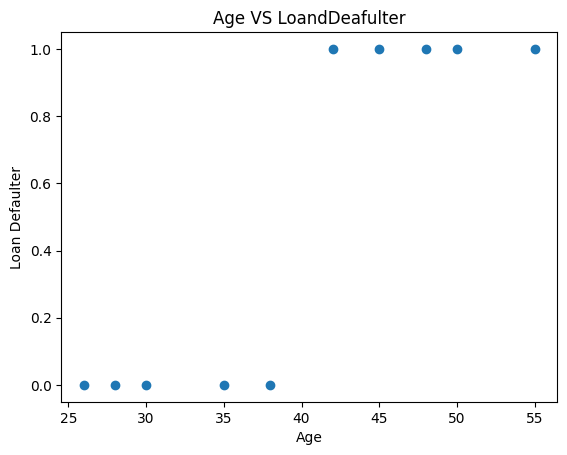

In [10]:
#Lets plot scatter plot between Age & Loan
plt.scatter(df['Age'],df[' loan(yes/no)'])
plt.title("Age VS LoandDeafulter")
plt.xlabel("Age")
plt.ylabel("Loan Defaulter")
plt.show()

OBSERVATION: As per the above plot high the age there is a risk to be defautler.

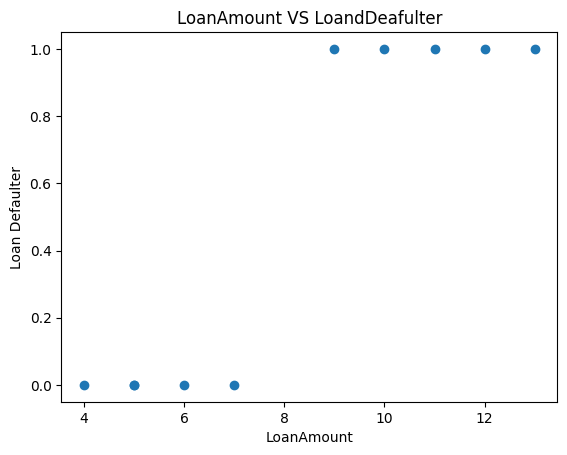

In [11]:
plt.scatter(df[' LoanAmount(lakhs)'],df[' loan(yes/no)'])
plt.title("LoanAmount VS LoandDeafulter")
plt.xlabel("LoanAmount")
plt.ylabel("Loan Defaulter")
plt.show()

OBSERVATION: As per the above plot Loan Defaulter are having high Loan Amount.

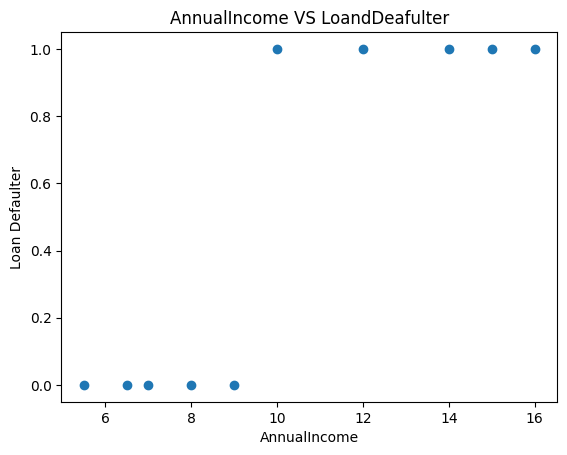

In [12]:
plt.scatter(df['AnnualIncome(lakhs)'],df[' loan(yes/no)'])
plt.title("AnnualIncome VS LoandDeafulter")
plt.xlabel("AnnualIncome")
plt.ylabel("Loan Defaulter")
plt.show()

OBSERVATION: As per above plot people with high income seems to be the loan defaulters.

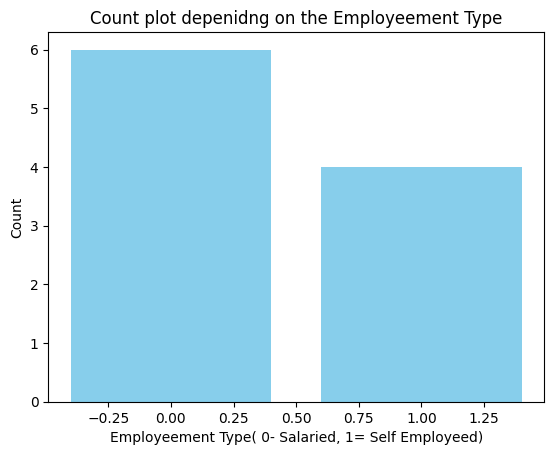

In [13]:
#Lets find the count plot based on the Employeement type
cnt = df[' EmploymentType_Self-Employed'].value_counts()

#Let plot the bar graph
plt.bar(cnt.index, cnt.values, color="skyblue")
plt.title("Count plot depenidng on the Employeement Type")
plt.xlabel("Employeement Type( 0- Salaried, 1= Self Employeed)")
plt.ylabel("Count")
plt.show()

OBSERVATION: Provided data set is having 6 people Salaried while 4 are self Employeed.

In [14]:
#Lets scale the numeric columns
scaler = StandardScaler()
num_cols = ['Age','AnnualIncome(lakhs)','CreditScore(300-900)',
            ' LoanAmount(lakhs)',' LoanTerm(years)']
df[num_cols]= scaler.fit_transform(df[num_cols])
df[num_cols]

,Age,AnnualIncome(lakhs),CreditScore(300-900),LoanAmount(lakhs),LoanTerm(years)
0,-1.242924,-1.067989,0.838548,-1.045953,-1.077084
1,0.563034,0.477785,-0.147979,0.588348,0.236433
2,-0.499294,-0.646414,1.578444,-0.719092,-0.551677
3,1.094198,1.320934,-1.134506,1.242069,1.549950
4,-1.030458,-0.927464,0.591916,-1.045953,-1.077084
5,0.244335,-0.084315,-0.641243,0.261488,0.236433
6,-1.455389,-1.349039,1.085180,-1.372813,-1.339788
7,0.881732,1.039884,-0.887875,0.915209,0.761840
8,-0.180596,-0.365365,0.345285,-0.392232,-0.288974
9,1.625362,1.601983,-1.627770,1.568929,1.549950


In [15]:
#Final df after being scaling and encoding
df

,Age,AnnualIncome(lakhs),CreditScore(300-900),LoanAmount(lakhs),LoanTerm(years),loan(yes/no),EmploymentType_Self-Employed
0,-1.242924,-1.067989,0.838548,-1.045953,-1.077084,0,0
1,0.563034,0.477785,-0.147979,0.588348,0.236433,1,1
2,-0.499294,-0.646414,1.578444,-0.719092,-0.551677,0,0
3,1.094198,1.320934,-1.134506,1.242069,1.549950,1,1
4,-1.030458,-0.927464,0.591916,-1.045953,-1.077084,0,0
5,0.244335,-0.084315,-0.641243,0.261488,0.236433,1,0
6,-1.455389,-1.349039,1.085180,-1.372813,-1.339788,0,0
7,0.881732,1.039884,-0.887875,0.915209,0.761840,1,1
8,-0.180596,-0.365365,0.345285,-0.392232,-0.288974,0,0
9,1.625362,1.601983,-1.627770,1.568929,1.549950,1,1


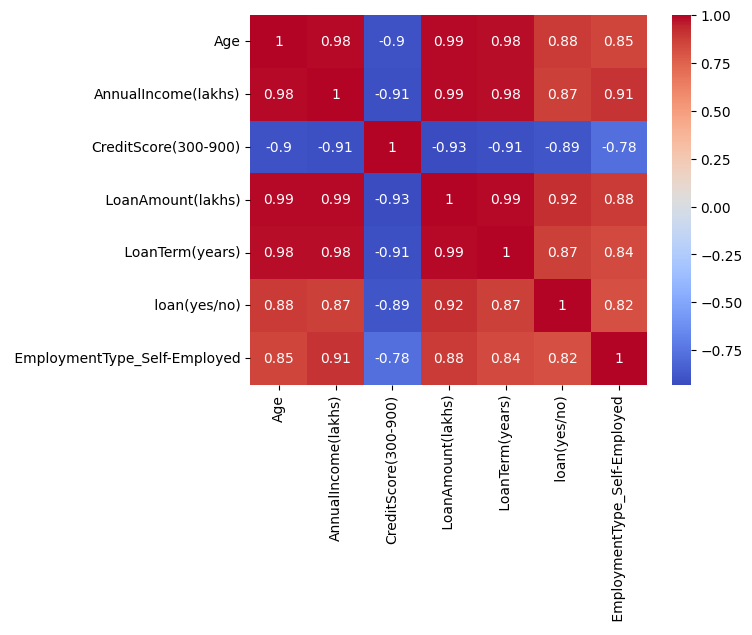

In [16]:
#Lets check the correlation between the input features:
df_corr = df.corr()
sns.heatmap(df_corr, annot = True, cmap='coolwarm')
plt.show()

In [17]:
df[' loan(yes/no)'].value_counts()

 loan(yes/no)
0    5
1    5
Name: count, dtype: int64

In [18]:
#Train & Test Split
x = df[['Age', 'AnnualIncome(lakhs)', 'CreditScore(300-900)',
       ' LoanAmount(lakhs)', ' LoanTerm(years)', 
       ' EmploymentType_Self-Employed']]
y = df[' loan(yes/no)']

In [19]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [20]:
#lets create KNN model
knn =KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [21]:
# Predict on the training and testing set
y_pred_train_knn = knn.predict(x_train)
y_pred_test_knn = knn.predict(x_test)

In [22]:
# Calculate training and testing accuracy
training_accuracy = accuracy_score(y_train, y_pred_train_knn)
testing_accuracy = accuracy_score(y_test, y_pred_test_knn)
print("\nK-Nearest Neighbors (KNN)")
print(f"Training Accuracy: {training_accuracy}")
print(f"Testing Accuracy: {testing_accuracy}")




K-Nearest Neighbors (KNN)
Training Accuracy: 1.0
Testing Accuracy: 1.0


In [23]:
y_pred_prob_knn = knn.predict_proba(x_test)[:, 1]
results_df = pd.DataFrame({
    'Actual Label': y_test,
    'Predicted Label': y_pred_test_knn,
    'Predicted Probability': y_pred_prob_knn
})

results_df.head()

,Actual Label,Predicted Label,Predicted Probability
8,0,0,0.333333
1,1,1,1.000000


In [24]:
#Consufion matrix
con_matrix = confusion_matrix(y_test, y_pred_test_knn)
print("Confusion Matrix:")
print(con_matrix)

Confusion Matrix:
[[1 0]
 [0 1]]


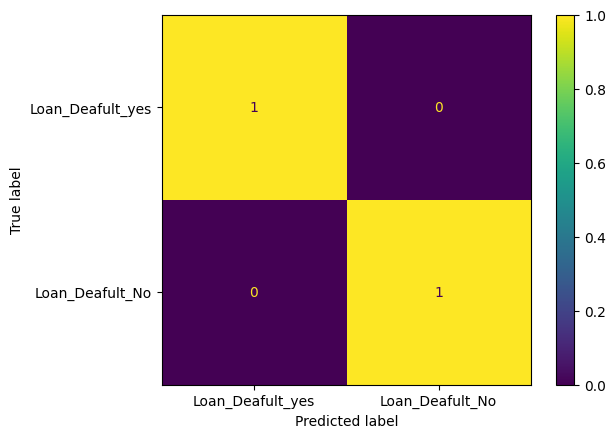

In [25]:
#Lets display the confusion matrix
cm_display = ConfusionMatrixDisplay(confusion_matrix=con_matrix,display_labels = ["Loan_Deafult_yes", "Loan_Deafult_No"])
cm_display.plot()

In [26]:
#Lets get the classification report
print("\t\tK-Nearest Neighbors Classification Report:")
print("\t\t-----------------------------------")
print(classification_report(y_test, y_pred_test_knn))

		K-Nearest Neighbors Classification Report:
		-----------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [27]:
# Save model
import pickle
with open("knn_model.pkl", "wb") as f:
    pickle.dump(knn, f)

# Save scaler
with open("knn_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model and scaler saved!")

Model and scaler saved!


#Implement the same using DecisionTree Classifier Model

In [28]:
from sklearn.tree import DecisionTreeClassifier

In [29]:
# Lets fit the training data to Decisiontree Classification model
dt_class = DecisionTreeClassifier(random_state=42)
dt_class.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [30]:
#Predict on the test data
dt_y_pred = dt_class.predict(x_test)
dt_y_pred_proba = dt_class.predict_proba(x_test)

In [31]:
# lets display the Actual VS Predicted Labels along with the Probabilities:
# Determine the class order
class_order = dt_class.classes_
print("Class order:", class_order)

# Create a DataFrame to display actual and predicted labels with probabilities
results_df = pd.DataFrame({
    'Actual Label': y_test,
    'Predicted Label': dt_y_pred,
})

# Add predicted probabilities with correct class names
for i, class_name in enumerate(class_order):
    results_df[f'Predicted Probability {class_name}'] = np.round(dt_y_pred_proba[:, i], 2)

# Display the first few rows of the results DataFrame
results_df.head()

Class order: [0 1]


,Actual Label,Predicted Label,Predicted Probability 0,Predicted Probability 1
8,0,0,1.0,0.0
1,1,1,0.0,1.0


In [32]:
## Calculate training and testing accuracy
print("\nDecision Tree Classifier:")
training_accuracy =  accuracy_score(y_train, dt_class.predict(x_train))
testing_accuracy = accuracy_score(y_test, dt_y_pred)

print(f"Training Accuracy: {training_accuracy}")
print(f"Testing Accuracy: {testing_accuracy}")


Decision Tree Classifier:
Training Accuracy: 1.0
Testing Accuracy: 1.0


In [33]:
#Lets check the classification report
print("Decision tree classifier classification report:")
print(classification_report(y_test, dt_y_pred))

Decision tree classifier classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



Confusion Matrix:
[[1 0]
 [0 1]]


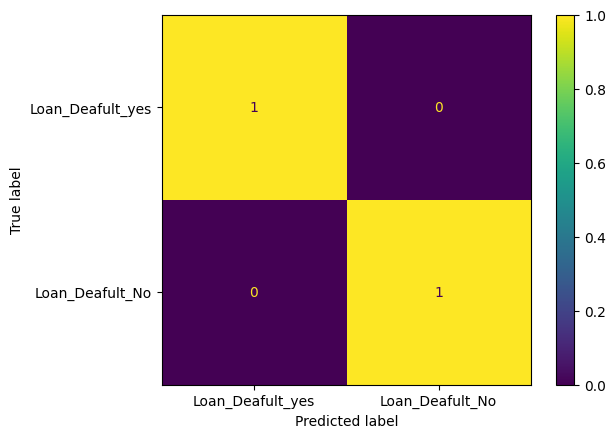

In [34]:
#Lets check the confusion matrix
#Consufion matrix
dt_con_matrix = confusion_matrix(y_test, dt_y_pred)
print("Confusion Matrix:")
print(dt_con_matrix)

cm_display = ConfusionMatrixDisplay(dt_con_matrix, display_labels = ["Loan_Deafult_yes", "Loan_Deafult_No"])
cm_display.plot()


OBSERVATIONS: On the provided dataset both KNN as well Decision Tree Classifier has provided same result with both having Training & Testing Acvuray as 100%.

Interpretation:

1)Identify high-risk customers:
For the provided data people falling under the below are Loan Defaulter/Risky:
 Age>40 Years
 Employeement Type: Self Employeed
 Credit Score<700
 

2)What patterns lead to loan default? Prople with credit score less than 700 and are Self EMployeed and having Age >40 are the loan defaulter.

3)How do credit score and income influence predictions? As per the correlation matrix Annual Income and Credit Score are having negative(-0.01) score. Credit score has negative correlation with the Loan Defaulter. If the credit scaore increases that mean there is a less change for a person to be a loan defaulter and vice-versa. 

4)Suggest banking policies based on model output.
If model predicts as 0.00 that mean the customer is not a risky customer and Bank can proceed to grant the Loan.
If model predicts as 1.00 that means model predicted this customer as Riskly Customer so bank has to Auto Reject the Loan Application. 

5)Compare KNN with Decision Trees for this problem. 
For the provided dataset can see both KNN & Decisiontree provided same Accuracy and result.

6)What happens if LoanAmount dominates distance calculation? 
In case where the LoanAmount dominates the distance in KNN the model tends to be Baised and ignores other important features.

7)Should KNN be used in real-time loan approval systems?
Yes, KNN can be used for real-time loan approval system during the following condition:
1. Where dataset is small to median.
2. Just a base-line model is required.
3. All the features are well scaled.

Usually real word financial data has several features and KNN performs poorly in high dimenstionaly spaces due to curse of dimentionality.

However the following are the better models for the Real Time Loan APproval systems.
1. Logistic Regression.
2. Decision Tree/Random Forest Classifiers.
3. Gradient Boosting.
